# A Zoning Mismatch Index for the San Francisco Bay Area
### Where the region needs homes vs. what local rules allow — and what 2018–2025 permit data reveals
*Python Programming DSBA 2025/26 course project · Andrew Shumilo (solo). Live app:
[bay-area-zmi.streamlit.app](https://bay-area-zmi.streamlit.app)*

## Abstract

The Bay Area must plan for **441,176 new homes in 2023–2031** under the state's Regional Housing
Needs Allocation (RHNA), yet the region has under-delivered in every previous cycle. This project
builds a **Zoning Mismatch Index (ZMI)** for all **109 Bay Area jurisdictions**: a composite measure
of the gap between where housing *should* go (jobs, market prices, transit access — the "Demand"
pillar) and what local zoning *allows* (zoned site capacity, multifamily share — the "Capacity"
pillar), extended with a regulatory-friction pillar and validated against what was *actually
permitted* (state APR data, 2018–2025). The dataset is assembled from 12+ public sources — HCD's
Annual Progress Reports and the statewide 6th-cycle sites inventory, ABAG's RHNA plan, MTC/ABAG
regional layers (including the brand-new draft **SB 79 transit-oriented zoning overrides**, a law
that takes effect July 1, 2026), parcel-level zoning from UC Berkeley's Othering & Belonging
Institute, Zillow, ACS, and LODES — joined into one 109 × 92 master table.

Beyond ranking jurisdictions, the analysis yields one finding we believe is genuinely useful to
regional planners: **zoned "paper" capacity has decoupled from delivery.** Capacity declared in
5th-cycle housing elements (2015–2023) significantly predicts 2018–2025 permitting; capacity in the
new state-enforced 6th-cycle elements does not — because the RHNA mandate forced even the most
exclusionary towns to multiply zoned capacity 3–5×. Legal capacity has converged on paper, so
*process friction and feasibility, not zoning maps alone, are now the binding constraint* — which
is exactly where the index says state law SB 79 and fee/process reform will matter most. This is a
solo project: data collection pipeline, analysis, the report, and the web application are all my
own work.

## 1. Background: why "mismatch"?

California's RHNA process allocates housing *need* to jurisdictions — ABAG's 2023–31 methodology
deliberately sends most of it to **High-Opportunity, job- and transit-rich places**. But the
allocation says nothing about whether those places' zoning allows that housing, or whether their
approval process delivers it. The research literature measures the pieces separately:

* **Rules:** the Wharton WRLURI survey index (Gyourko et al.) and the NLP-derived **NZLUD**
  (Mleczko & Desmond 2023) quantify regulatory strictness;
* **Capacity:** Monkkonen, Lens & Manville ("*Built-out cities?*", 2024) show that self-reported
  **unbuilt zoned capacity × demand** predicts permits better than survey indices;
* **Friction:** Terner Center work documents impact fees of \$15k–\$77k per multifamily unit
  (~4× the non-CA average) and the failure of SB 9 (legalization without de-frictioning) vs.
  the success of the ADU reforms (~1 in 5 new CA homes after fees were capped and approval made
  ministerial);
* **Outcomes:** HCD's Annual Progress Reports give project-level permits by income band.

No public product combines these into a single, validated, jurisdiction-level diagnostic for the
Bay Area. That is what the ZMI does. Timing makes it relevant: CEQA infill exemptions (AB 130/SB 131)
took effect June 30 2025, **SB 79** (state zoning overrides near major transit) takes effect
**July 1 2026**, and ABAG adopted Plan Bay Area 2050+ in March 2026 while preparing the 7th RHNA
cycle. Full source list at the end of the notebook.

## 2. The dataset

One row = one jurisdiction (101 cities + 8 unincorporated county areas = **109 rows**). The master
table is assembled by `src/assemble_v3.py` from the sources below (each downloaded by the scripts
in `src/`; vintages differ and are documented per column).

| Source | What it contributes | Vintage |
|---|---|---|
| HCD Annual Progress Reports, Table A2 (project-level) | permits / entitlements / completions by income band | 2018–2025 |
| HCD/DGS statewide **6th-cycle sites inventory** (Tables A & B) | zoned "realistic capacity" per site, density, vacancy | 2023–31 elements |
| MTC 5th-cycle sites inventory | zoned capacity, previous cycle | 2015–23 elements |
| ABAG **Final RHNA Plan** (parsed from PDF incl. Solano sub-allocations) | housing need by income band | 2023–31 |
| OBI Bay Area zoning (parcel shapefiles → city shares) | single-family-only land share | 2020 |
| NZLUD (Mleczko–Desmond) | parking / lot-size / approval friction, ZRI | 2018–21 texts |
| Zillow ZHVI + ZORI | home values, market rents | latest month |
| ACS (via censusreporter API) | units, income, rent, tenure, race | 2022/2024 |
| LODES 8 | jobs (WAC) and resident workers (RAC) by block → jurisdiction | 2022 |
| MTC: PBA50 Growth Geographies, HQ Transit Areas, TPAs, EPCs | High-Resource / Transit-Rich / equity area shares | 2020–2026 |
| MTC **draft SB 79 TOD zones & stops** | land share under the new state override, by tier | April 2026 |
| MTC jobs/households/population | denominators | 2020 |

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import statsmodels.api as sm
from scipy import stats as sps

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', 100)

df = pd.read_csv('data/processed/bay_area_zmi_v3.csv')
yearly = pd.read_csv('data/processed/apr_permits_by_year.csv')
print(f'master table: {df.shape[0]} jurisdictions x {df.shape[1]} columns')
print(f'permits long table: {yearly.shape[0]} jurisdiction-years ({yearly.year.min()}-{yearly.year.max()})')
df.head(3)

master table: 109 jurisdictions x 92 columns
permits long table: 856 jurisdiction-years (2018-2025)


,jurisdiction,fipst,fipco,jobs_2020,households_2020,pop_2020,county,place_fips,key,permits1417_vlow,permits1417_low,permits1417_total,capacity5_units,density5_mean,n_sites5,jh_ratio_2020,rhna_very_low,rhna_low,rhna_moderate,rhna_above_moderate,rhna_total,permits1825_vlow,permits1825_low,permits1825_mod,permits1825_above,permits1825_total,permits2325_total,permits2325_vlow,permits2325_low,permits1825_adu,permits1825_mf24,permits1825_mf5,permits1825_sf,capacity6_units,capacity6_lower,density6_mean,sites6_vacant_share,n_sites6,capacity6_rezone_units,capacity_vintage,sf_share,mf_share,zhvi_latest,zhvi_yoy,zori_latest,zori_yoy,acs_geo,acs_units,acs_med_income,acs_med_rent,acs_med_value,acs_owner_share,acs_poc_share,place_fips5,nzlud_zri,nzlud_parking,nzlud_minlot,nzlud_adu_allowed,nzlud_mf_permitted,nzlud_approval_steps,jobs_2022,workers_2022,sb79_share,sb79_tier1_share,tpa_share,hqta_share,epc_share,hra_share,tra_share,jh_ratio_2022,permits1825_per_1k,permits1825_mf_per_1k,adu_share_1825,permits1825_belowmod_per_1k,capacity6_per_1k,capacity5_per_1k,cap_ratio_6_to_5,rhna_per_1k,rhna6_progress,rhna6_lowinc_progress,capacity_vs_rhna,mf_allowed_share,D_demand,C_capacity,F_friction,F_coverage,P_delivery,zmi_core,zmi_full,zmi_realized,C_capacity_5th,zmi_core_5th
0,Alameda,6,1,38905,34320,87460,Alameda,6001,alameda,51,33,339,4606.00,27.324324,41.0,1.133596,1421,818,868,2246,5353,491,194,197,2642,3524,1516,278,73,431,26,3005,62,1030.00,658.0,12.625000,0.250000,16.0,1485.0,6th_cycle,0.428685,0.571315,1.162241e+06,-0.032965,2883.359446,0.044694,place,32320.0,151346.0,2437.0,1160500.0,0.545204,0.598411,600562.0,NaN,NaN,NaN,NaN,NaN,NaN,30335.0,39066.0,0.093561,0.0,0.357605,0.564884,0.994284,0.369505,0.443359,0.938583,102.680653,88.315851,0.122304,19.959207,30.011655,134.207459,0.223621,155.973193,0.283206,0.156766,0.192415,0.571315,0.040313,0.721547,NaN,False,0.320051,-0.681234,-0.681234,-0.279738,0.989459,-0.949146
1,Albany,6,1,4925,7630,19285,Alameda,6001,albany,0,0,210,761.00,57.526316,61.0,0.645478,308,178,175,453,1114,60,47,136,208,451,251,28,17,161,8,268,14,1195.00,509.0,22.876712,0.164384,73.0,NaN,6th_cycle,0.695241,0.304759,1.272260e+06,0.009444,3144.583333,-0.027400,place,8070.0,144107.0,2445.0,1202200.0,0.531385,0.570310,600674.0,NaN,NaN,NaN,NaN,NaN,NaN,4466.0,8275.0,0.000000,0.0,0.600071,0.843820,0.994906,0.584001,0.646577,0.553408,59.108781,36.173001,0.356984,14.023591,156.618611,99.737877,1.570302,146.002621,0.225314,0.092593,1.072711,0.304759,0.250876,0.700786,NaN,False,-0.435435,-0.449910,-0.449910,0.686311,0.070122,0.180754
2,American Canyon,6,55,6210,5710,22390,Napa,6055,american canyon,49,37,220,1194.34,20.000000,61.0,1.087566,112,65,75,194,446,487,305,10,862,1664,795,192,111,54,0,1325,285,1194.34,NaN,NaN,NaN,NaN,NaN,5th_cycle_fallback,0.856479,0.143521,7.413219e+05,-0.024609,3182.611111,NaN,place,6131.0,121700.0,2537.0,692600.0,0.742652,0.795030,601640.0,2.925407,1.25,1.0,1.0,0.545455,2.0,5021.0,11106.0,0.000000,0.0,0.000000,0.000000,1.000000,0.000000,0.000000,0.818953,291.418564,232.049037,0.032452,138.704028,209.166375,209.166375,1.000000,78.108581,1.782511,1.711864,2.677892,0.143521,-0.598179,0.497599,-0.555388,True,2.374976,-1.095778,-1.651166,-2.973155,-0.062402,-0.535776


### 2.1 Field overview and data quality

92 columns: identifiers (3), denominators (jobs/households/population/units), need (RHNA by 4 income
bands), production (permits by band, two eras), capacity (5th & 6th cycle), zoning (single-family
share), prices (ZHVI/ZORI), demographics (ACS), friction (NZLUD), geography shares (SB 79 / transit /
high-resource / equity areas), and the derived pillar scores. Below: dtypes and the missingness
audit. **Every gap has a known reason** — none are silent data errors.

In [2]:
print('dtype counts:', df.dtypes.value_counts().to_dict())
print('duplicate jurisdiction keys:', df['key'].duplicated().sum())

missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
reasons = {
    'nzlud_zri': 'NZLUD covers 36/109 Bay jurisdictions (sample design of the source)',
    'nzlud_parking': 'same', 'nzlud_minlot': 'same', 'nzlud_adu_allowed': 'same',
    'nzlud_mf_permitted': 'same', 'nzlud_approval_steps': 'same', 'F_friction': 'needs NZLUD',
    'zori_latest': 'Zillow publishes rent index only for larger cities (82/109)',
    'zori_yoy': 'same', 'zhvi_latest': 'Zillow city coverage (100/109)', 'zhvi_yoy': 'same',
    'jobs_2022': 'LODES covers incorporated places; 8 unincorporated areas aggregated separately',
    'workers_2022': 'same', 'jh_ratio_2022': 'needs jobs_2022',
    'place_fips5': 'unincorporated areas have no Census place FIPS',
    'capacity6_rezone_units': 'only 42 jurisdictions filed Table B (rezone) sites',
    'acs_med_value': 'ACS suppresses estimates for very small geographies',
    'acs_med_rent': 'ACS suppresses estimates for very small geographies',
    'permits2325_total': 'no 2023-25 APR filings matched (rare)',
    'cap_ratio_6_to_5': 'needs both capacity vintages',
    'n_sites6': 'the 10 jurisdictions imputed from APR/5th cycle (see capacity_vintage)',
    'sites6_vacant_share': 'the 10 jurisdictions imputed (no site-level vacancy)',
    'capacity6_lower': 'the 10 jurisdictions imputed (no income-band split)',
    'density6_mean': 'imputed or no per-site density reported for these sites',
    'density5_mean': 'no per-site density reported in the 5th-cycle inventory',
    'capacity5_units': '1 jurisdiction absent from the MTC 5th-cycle inventory',
    'capacity5_per_1k': '1 jurisdiction absent from the MTC 5th-cycle inventory',
    'n_sites5': '1 jurisdiction absent from the MTC 5th-cycle inventory',
}
audit = pd.DataFrame({'n_missing': missing,
                      'reason': [reasons.get(c, '-') for c in missing.index]})
audit

dtype counts: {dtype('float64'): 60, dtype('int64'): 26, dtype('O'): 5, dtype('bool'): 1}
duplicate jurisdiction keys: 0


,n_missing,reason
F_friction,73,needs NZLUD
nzlud_zri,73,NZLUD covers 36/109 Bay jurisdictions (sample ...
nzlud_approval_steps,73,same
nzlud_mf_permitted,73,same
nzlud_adu_allowed,73,same
nzlud_minlot,73,same
nzlud_parking,73,same
capacity6_rezone_units,67,only 42 jurisdictions filed Table B (rezone) s...
zori_yoy,38,same
zori_latest,27,Zillow publishes rent index only for larger ci...


### 2.2 Cleanup

Most cleaning happens in the pipeline scripts and is *documented as data*, not silently fixed:

* **Inconsistent jurisdiction names** across sources ("St. Helena" vs "Saint Helena", "ALAMEDA
  COUNTY" vs "Unincorporated Alameda") → a normalization function + canonical `key`; all 109 rows
  match across all sources (verified below).
* **RHNA PDF quirks** — two-column layout and the Solano subregion (whose 8 sub-allocations sit in
  an appendix) → parsed with per-row consistency checks; the extracted table sums to **exactly
  441,176**, the official regional determination.
* **The 10 jurisdictions missing from the state's 6th-cycle sites map** → imputed from APR Table C
  (2 cities) or 5th-cycle capacity (8), recorded in `capacity_vintage` so nothing is hidden.
* Numeric coercion of capacity/permit fields (`errors='coerce'`), no duplicate keys, and **no rows
  are dropped**: with N=109, deleting a city would bias the regional picture, so NaN-tolerant
  methods are used instead. Extreme values are winsorized at p5/p95 *only* inside z-scores.

In [3]:
# verify the cleanup contract
assert df['key'].is_unique
assert len(df) == 109
assert int(df['rhna_total'].sum()) == 441176, 'RHNA must sum to the official determination'
num_cols = df.select_dtypes(include=[np.number]).columns
print(f'numeric columns: {len(num_cols)}; all coerced numeric:',
      all(np.issubdtype(df[c].dtype, np.number) for c in num_cols))
print('capacity_vintage:', df['capacity_vintage'].value_counts().to_dict())
df['county'] = df['county'].astype('category')

# example of a real outlier kept (not deleted) but winsorized inside z-scores:
out = df.nlargest(3, 'jh_ratio_2022')[['jurisdiction','jobs_2022','acs_units','jh_ratio_2022']]
print('\nlargest jobs-housing ratios (Colma: cemeteries + retail, ~1.5k residents):')
out

numeric columns: 86; all coerced numeric: True
capacity_vintage: {'6th_cycle': 99, '5th_cycle_fallback': 8, 'apr_tableC_2023plus': 2}

largest jobs-housing ratios (Colma: cemeteries + retail, ~1.5k residents):


,jurisdiction,jobs_2022,acs_units,jh_ratio_2022
16,Colma,4581.0,615.0,7.448780
45,Menlo Park,65976.0,13388.0,4.927995
60,Palo Alto,109011.0,29241.0,3.728019


## 3. Descriptive statistics

Means, medians and standard deviations for the core numeric fields.
Note the *skew everywhere*: median permits per 1k households (2018–25) is far below the mean —
production is concentrated in a few jurisdictions; capacity and prices behave the same way.

In [4]:
desc_cols = {
    'jh_ratio_2022': 'jobs per housing unit (2022)',
    'zhvi_latest': 'home value, $ (Zillow ZHVI)',
    'zori_latest': 'market rent, $/mo (Zillow ZORI)',
    'acs_med_income': 'median household income, $',
    'permits1825_per_1k': 'units permitted 2018-25 per 1k households',
    'capacity6_per_1k': 'zoned capacity (6th cycle) per 1k households',
    'rhna_per_1k': 'RHNA 2023-31 per 1k households',
    'sf_share': 'share of residential land zoned single-family-only',
}
d = df[list(desc_cols)].describe().T
d['median'] = df[list(desc_cols)].median()
d = d[['count','mean','median','std','min','max']].round(2)
d.index = [f'{k} — {v}' for k, v in desc_cols.items()]
d

,count,mean,median,std,min,max
jh_ratio_2022 — jobs per housing unit (2022),101.0,1.24,1.03,0.98,0.28,7.45
"zhvi_latest — home value, $ (Zillow ZHVI)",100.0,1689383.72,1274917.36,1312604.74,447218.03,8203578.14
"zori_latest — market rent, $/mo (Zillow ZORI)",82.0,3375.74,3208.85,874.56,2130.78,7054.90
"acs_med_income — median household income, $",109.0,156390.17,145029.00,51537.35,79478.00,250001.00
permits1825_per_1k — units permitted 2018-25 per 1k households,109.0,86.57,72.38,65.53,6.18,322.22
capacity6_per_1k — zoned capacity (6th cycle) per 1k households,109.0,115.55,94.12,101.52,0.00,585.24
rhna_per_1k — RHNA 2023-31 per 1k households,109.0,139.47,137.84,52.72,60.24,267.03
sf_share — share of residential land zoned single-family-only,109.0,0.81,0.87,0.18,0.00,1.00


## 4. Overview plots

Five figures — a distribution, a relationship, a ranking, a map, and a correlation structure —
each with a short read.

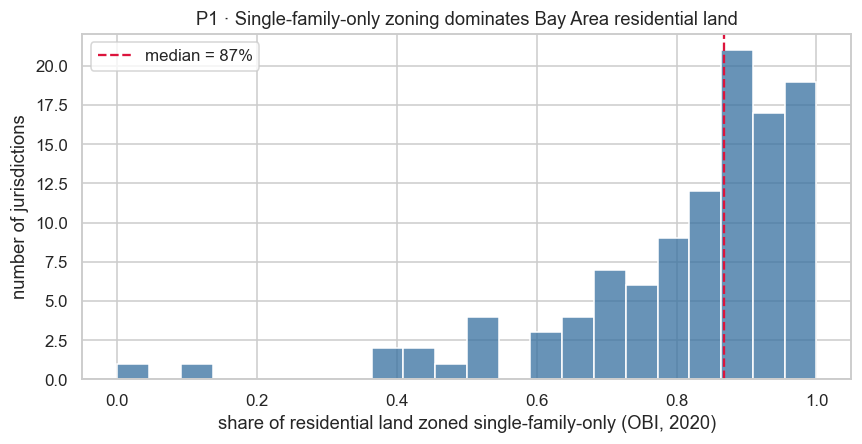

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.2))
sns.histplot(df['sf_share'], bins=22, ax=ax, color='#356f9f')
ax.axvline(df['sf_share'].median(), color='crimson', ls='--',
           label=f"median = {df['sf_share'].median():.0%}")
ax.set_xlabel('share of residential land zoned single-family-only (OBI, 2020)')
ax.set_ylabel('number of jurisdictions')
ax.set_title('P1 · Single-family-only zoning dominates Bay Area residential land')
ax.legend(); plt.tight_layout(); plt.show()

**Read:** in the median jurisdiction, ~85% of residential land allows nothing but
single-family homes; a long left tail (Emeryville, San Francisco) is the exception. This is the
*Capacity* pillar's strongest lever — it is why state laws SB 9/SB 79 target exactly this margin.

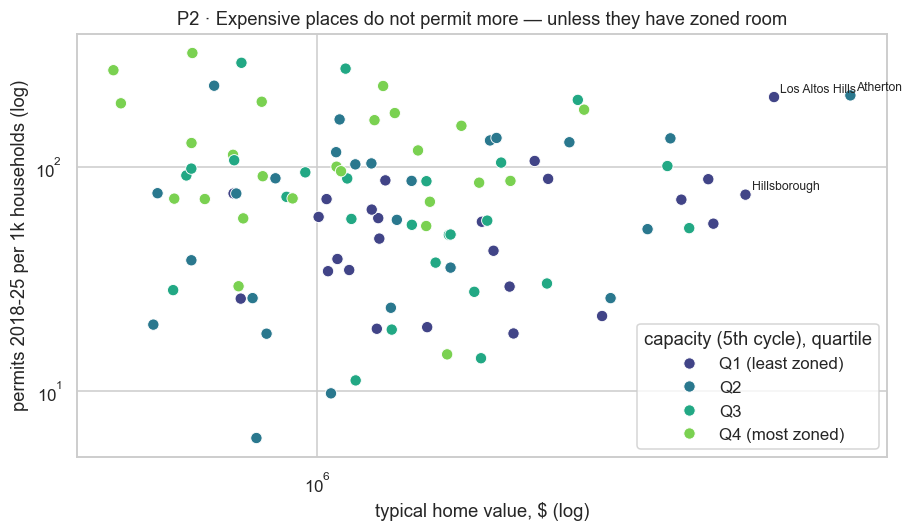

In [6]:
d = df.dropna(subset=['zhvi_latest', 'permits1825_per_1k', 'capacity5_per_1k']).copy()
d['capacity (5th cycle), quartile'] = pd.qcut(d['capacity5_per_1k'], 4,
                                              labels=['Q1 (least zoned)','Q2','Q3','Q4 (most zoned)'])
fig, ax = plt.subplots(figsize=(8.5, 5))
sns.scatterplot(data=d, x='zhvi_latest', y='permits1825_per_1k',
                hue='capacity (5th cycle), quartile', palette='viridis', s=55, ax=ax)
ax.set_yscale('log'); ax.set_xscale('log')
ax.set_xlabel('typical home value, $ (log)'); ax.set_ylabel('permits 2018-25 per 1k households (log)')
ax.set_title('P2 · Expensive places do not permit more — unless they have zoned room')
for _, r in d.nlargest(3, 'zhvi_latest').iterrows():
    ax.annotate(r['jurisdiction'], (r['zhvi_latest'], r['permits1825_per_1k']),
                fontsize=8, xytext=(4, 3), textcoords='offset points')
plt.tight_layout(); plt.show()

**Read:** price alone (the demand signal) barely orders production; the color gradient does —
high-capacity quartiles sit visibly higher. Demand without legal room produces prices, not permits.
Section 7 tests this formally.

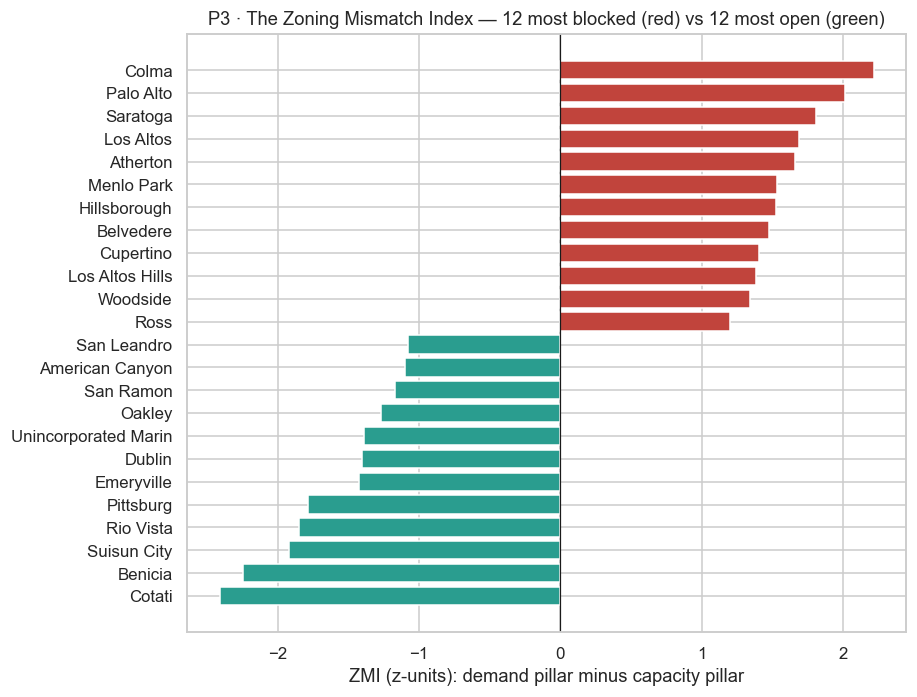

In [7]:
top = df.nlargest(12, 'zmi_core'); bot = df.nsmallest(12, 'zmi_core')
show = pd.concat([top, bot]).sort_values('zmi_core')
fig, ax = plt.subplots(figsize=(8.5, 6.5))
colors = ['#2a9d8f' if v < 0 else '#c1443c' for v in show['zmi_core']]
ax.barh(show['jurisdiction'], show['zmi_core'], color=colors)
ax.set_xlabel('ZMI (z-units): demand pillar minus capacity pillar')
ax.set_title('P3 · The Zoning Mismatch Index — 12 most blocked (red) vs 12 most open (green)')
ax.axvline(0, color='k', lw=0.8); plt.tight_layout(); plt.show()

**Read:** the red end is the Peninsula/South Bay exclusion belt — Colma, Palo Alto, Saratoga,
Los Altos, Atherton, Hillsborough — places with extreme demand and minimal legal capacity. The green
end combines genuinely low-demand exurbs (Solano County) with Emeryville, a high-demand city that
simply zones for housing. The index separates *"can't build because blocked"* from *"doesn't build
because nobody asks"* — the distinction prescriptions depend on.

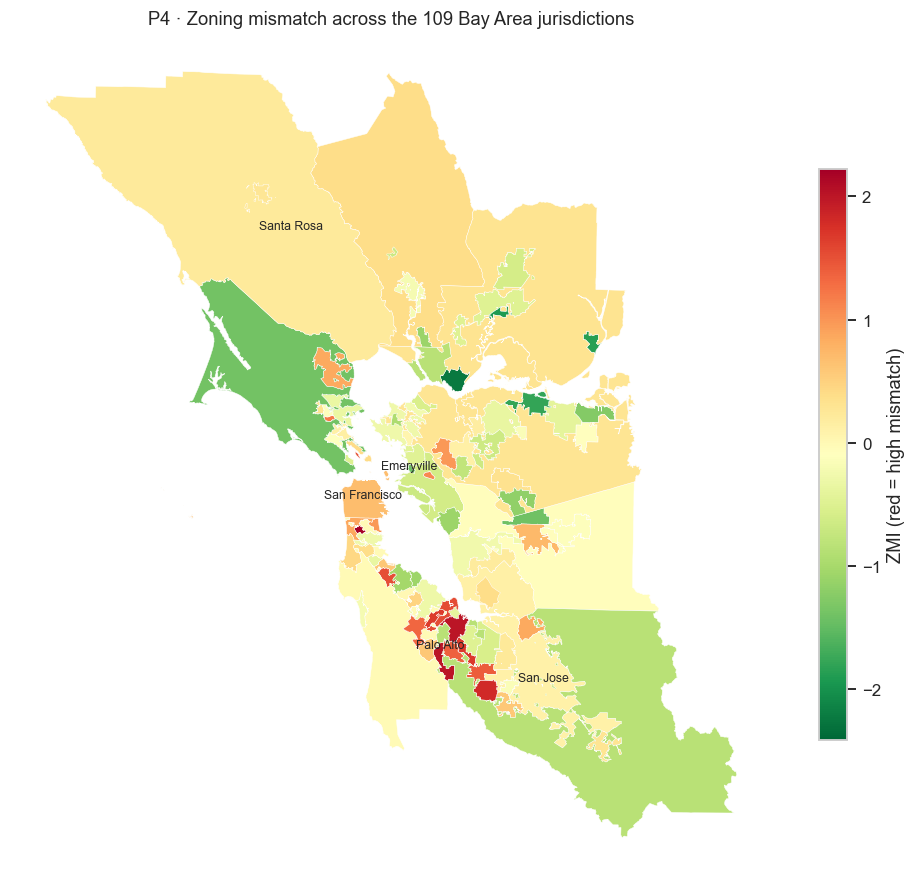

In [8]:
jur = gpd.read_file('data/raw/v3/jurisdictions.geojson').to_crs(3310)
import re as _re
import sys as _sys
_sys.path.insert(0, 'src')
from zmi_ingest import jkey as _jkey
jur['key'] = [_jkey(n, c) for n, c in zip(jur['jurname'], jur['coname'])]
jur = jur.dissolve(by='key').merge(df[['key','zmi_core','jurisdiction']], on='key')
fig, ax = plt.subplots(figsize=(9, 9))
jur.plot(column='zmi_core', cmap='RdYlGn_r', legend=True, ax=ax,
         edgecolor='white', linewidth=0.3,
         legend_kwds={'label': 'ZMI (red = high mismatch)', 'shrink': 0.6})
ax.set_axis_off()
ax.set_title('P4 · Zoning mismatch across the 109 Bay Area jurisdictions')
for name in ['Palo Alto', 'San Francisco', 'Emeryville', 'Santa Rosa', 'San Jose']:
    row = jur[jur['jurisdiction'] == name]
    if len(row):
        pt = row.geometry.representative_point().iloc[0]
        ax.annotate(name, (pt.x, pt.y), fontsize=8, ha='center')
plt.tight_layout(); plt.show()

**Read:** mismatch is *spatially organized*: a contiguous red corridor follows the Peninsula
and the South Bay foothills — precisely the job- and transit-rich core — while the green periphery
is where the region's zoned capacity actually sits. The map is the geography of the problem ABAG's
RHNA tries to correct.

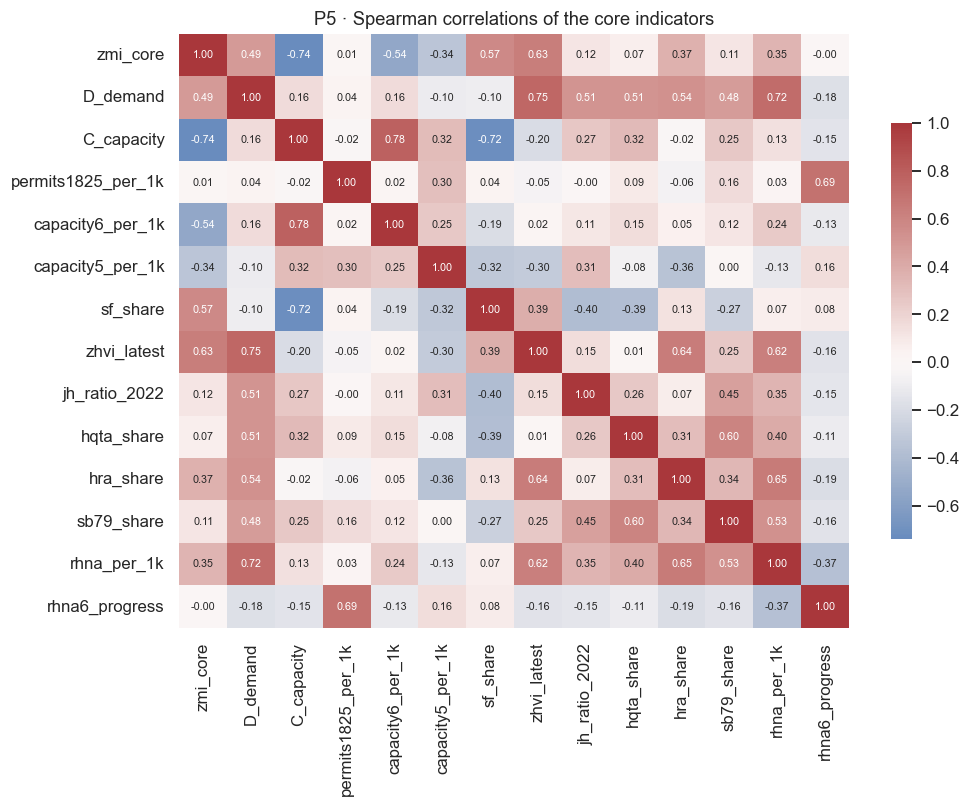

In [9]:
hm_cols = ['zmi_core','D_demand','C_capacity','permits1825_per_1k','capacity6_per_1k',
           'capacity5_per_1k','sf_share','zhvi_latest','jh_ratio_2022','hqta_share',
           'hra_share','sb79_share','rhna_per_1k','rhna6_progress']
corr = df[hm_cols].corr(method='spearman')
fig, ax = plt.subplots(figsize=(9.5, 7.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', center=0,
            annot_kws={'size': 7}, ax=ax, cbar_kws={'shrink': 0.7})
ax.set_title('P5 · Spearman correlations of the core indicators')
plt.tight_layout(); plt.show()

**Read (three cells worth noticing):** (1) `rhna_per_1k` correlates strongly with `D_demand`
— ABAG indeed assigns need where demand is, so a deliverability gap in high-demand cities is a
direct threat to the RHNA; (2) `sb79_share` tracks `hqta_share` and demand — the new state override
lands precisely in high-mismatch territory; (3) `capacity6_per_1k` is *weakly* related to past
permits — first hint of the decoupling result in §7.

## 5. Detailed overview — four comparisons

### C1 · What separates the most-blocked from the most-open jurisdictions?

In [10]:
grp = pd.concat([df.nlargest(15, 'zmi_core').assign(group='Top-15 mismatch'),
                 df.nsmallest(15, 'zmi_core').assign(group='Bottom-15 mismatch')])
cmp_cols = ['zhvi_latest','acs_med_income','jh_ratio_2022','sf_share','capacity6_per_1k',
            'permits1825_per_1k','permits1825_mf_per_1k','adu_share_1825',
            'rhna_per_1k','rhna6_progress','hqta_share','acs_poc_share']
t = grp.groupby('group')[cmp_cols].median().T.round(2)
t['ratio top/bottom'] = (t['Top-15 mismatch'] / t['Bottom-15 mismatch']).round(2)
t

group,Bottom-15 mismatch,Top-15 mismatch,ratio top/bottom
zhvi_latest,737138.23,3983810.79,5.40
acs_med_income,121204.00,250001.00,2.06
jh_ratio_2022,1.00,0.92,0.92
sf_share,0.69,0.99,1.43
capacity6_per_1k,209.17,39.52,0.19
permits1825_per_1k,54.51,88.17,1.62
permits1825_mf_per_1k,15.97,1.42,0.09
adu_share_1825,0.07,0.54,7.71
rhna_per_1k,109.67,162.46,1.48
rhna6_progress,0.13,0.27,2.08


**Read — and a trap this table exposes.** The top-mismatch group has **5.4× the home
values, 2× the income, 3.4× the transit-served land share, 1.5× the RHNA need per household, and
one-fifth the zoned capacity** — and a visibly whiter population. But look at total permits per 1k:
the *blocked* group appears to permit **more** (median 88 vs 55 per 1k). The resolution is in the
next two rows: their **multifamily permitting is ~1.4 units per 1k households over eight years —
an 11× gap against the open group (16.0)** — and **54% of everything they permit is an ADU**
(vs 7%), with much of the rest single-family tear-down rebuilds, which APR counts as new units.
Wealthy low-density towns look productive in headline counts while building essentially zero
apartments. Every "progress" metric that ignores unit structure flatters exactly the places the
mismatch index flags. This is why the analysis below switches to multifamily permits wherever
delivery at RHNA scale is the question.

### C2 · Who is the housing for? Permits vs need, by income band

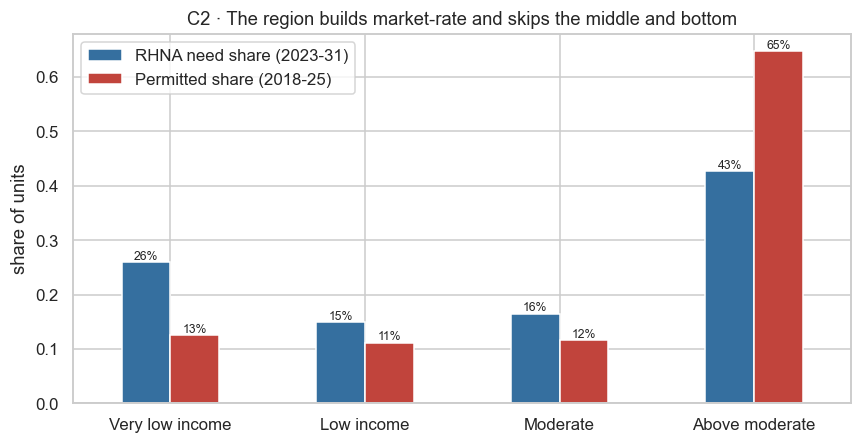

,RHNA need share (2023-31),Permitted share (2018-25)
Very low income,0.259,0.125
Low income,0.149,0.112
Moderate,0.165,0.116
Above moderate,0.426,0.647


In [11]:
bands = ['vlow','low','mod','above']
permit_share = df[[f'permits1825_{b}' for b in bands]].sum()
permit_share = permit_share / permit_share.sum()
rhna_share = df[['rhna_very_low','rhna_low','rhna_moderate','rhna_above_moderate']].sum()
rhna_share = rhna_share / rhna_share.sum()
comp = pd.DataFrame({'RHNA need share (2023-31)': rhna_share.values,
                     'Permitted share (2018-25)': permit_share.values},
                    index=['Very low income','Low income','Moderate','Above moderate'])
ax = comp.plot(kind='bar', figsize=(8, 4.2), color=['#356f9f', '#c1443c'], rot=0)
ax.set_ylabel('share of units')
ax.set_title('C2 · The region builds market-rate and skips the middle and bottom')
for c in ax.containers:
    ax.bar_label(c, labels=[f'{v:.0%}' for v in c.datavalues], fontsize=8)
plt.tight_layout(); plt.show()
comp.round(3)

**Read:** ~26% of the need is very-low-income, but only a small fraction of 2018–25 permits
were; above-moderate (market-rate) units run far ahead of their need share. Any mismatch index that
ignored income bands would miss that the shortfall is overwhelmingly an *affordability-band*
shortfall.

### C3 · The capacity regime change: 5th vs 6th cycle

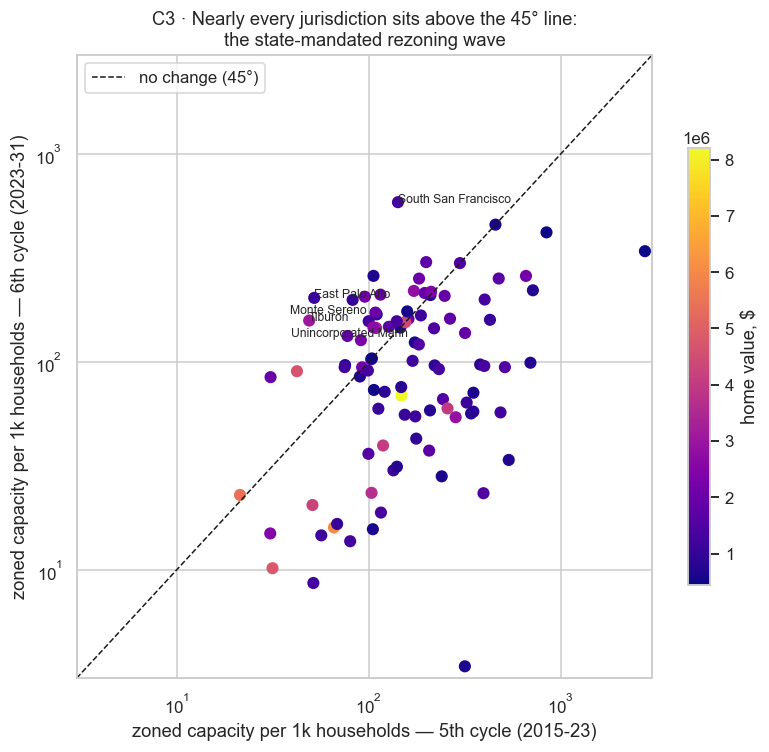

jurisdictions with biggest forced capacity expansion (ratio 6th/5th):


,jurisdiction,county,capacity5_per_1k,capacity6_per_1k,cap_ratio_6_to_5,sf_share,zhvi_latest
49,Monte Sereno,Santa Clara,38.9,169.5,4.4,1.0,NaN
90,South San Francisco,San Mateo,141.7,585.2,4.1,0.7,1238304.2
25,East Palo Alto,San Mateo,51.9,202.8,3.9,0.8,1037416.1
96,Unincorporated Marin,Marin,39.1,131.9,3.4,0.7,NaN
93,Tiburon,Marin,48.9,157.8,3.2,0.9,3078398.8
58,Orinda,Contra Costa,30.7,84.3,2.7,1.0,2005280.9
57,Oakley,Contra Costa,105.7,258.7,2.4,0.9,665615.4
105,Walnut Creek,Contra Costa,82.3,198.4,2.4,0.9,1043420.1


In [12]:
d = df.dropna(subset=['capacity5_per_1k','capacity6_per_1k']).copy()
fig, ax = plt.subplots(figsize=(7.5, 7))
sc = ax.scatter(d['capacity5_per_1k'], d['capacity6_per_1k'],
                c=d['zhvi_latest'], cmap='plasma', s=48)
lim = [3, 3000]
ax.plot(lim, lim, 'k--', lw=1, label='no change (45°)')
ax.set_xscale('log'); ax.set_yscale('log'); ax.set_xlim(lim); ax.set_ylim(lim)
plt.colorbar(sc, label='home value, $', shrink=0.7)
ax.set_xlabel('zoned capacity per 1k households — 5th cycle (2015-23)')
ax.set_ylabel('zoned capacity per 1k households — 6th cycle (2023-31)')
ax.set_title('C3 · Nearly every jurisdiction sits above the 45° line:\nthe state-mandated rezoning wave')
for _, r in d.nlargest(5, 'cap_ratio_6_to_5').iterrows():
    ax.annotate(r['jurisdiction'], (r['capacity5_per_1k'], r['capacity6_per_1k']), fontsize=8)
ax.legend(); plt.tight_layout(); plt.show()
print('jurisdictions with biggest forced capacity expansion (ratio 6th/5th):')
d.nlargest(8, 'cap_ratio_6_to_5')[['jurisdiction','county','capacity5_per_1k',
    'capacity6_per_1k','cap_ratio_6_to_5','sf_share','zhvi_latest']].round(1)

**Read:** the 6th-cycle housing-element process (with real HCD enforcement and builder's-remedy
risk) pushed almost everyone above the 45° line, and the *largest* multiples belong to wealthy,
heavily single-family towns — Monte Sereno, Tiburon, Orinda. Paper capacity converged. §7/H2 shows
the consequence: 6th-cycle capacity no longer predicts who actually builds.

### C4 · Production over time: blocked vs open jurisdictions, 2018–2025

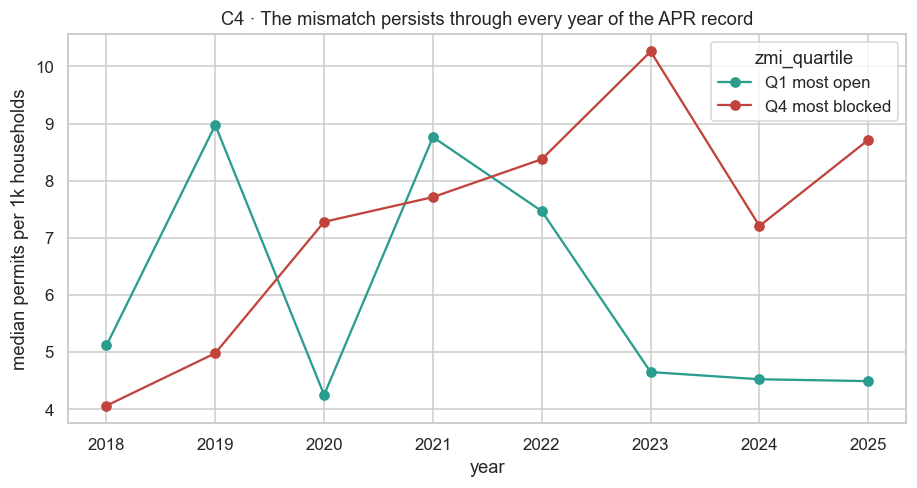

zmi_quartile,Q1 most open,Q2,Q3,Q4 most blocked
year,,,,
2018,5.12,4.01,3.75,4.06
2019,8.97,5.94,7.32,4.98
2020,4.25,8.20,3.19,7.28
2021,8.76,7.31,6.41,7.71
2022,7.47,11.13,5.58,8.38
2023,4.65,8.26,8.18,10.26
2024,4.52,6.27,4.49,7.21
2025,4.49,8.49,7.38,8.71


In [13]:
q = df[['key','zmi_core','households_2020']].copy()
q['zmi_quartile'] = pd.qcut(q['zmi_core'], 4, labels=['Q1 most open','Q2','Q3','Q4 most blocked'])
y = yearly.merge(q, on='key')
y['rate'] = 1000 * y['total'] / y['households_2020']
ts = y.groupby(['year','zmi_quartile'])['rate'].median().unstack()
fig, ax = plt.subplots(figsize=(8.5, 4.6))
ts[['Q1 most open','Q4 most blocked']].plot(ax=ax, marker='o',
                                            color=['#2a9d8f','#c1443c'])
ax.set_ylabel('median permits per 1k households')
ax.set_title('C4 · The mismatch persists through every year of the APR record')
plt.tight_layout(); plt.show()
ts.round(2)

**Read:** the gap between the most-open and the most-blocked quartile persists through the
whole 2018–2025 window — including after the 2021–22 state reforms — though watch 2024–25: the
blocked quartile's median ticks up as 6th-cycle elements and ADU/SB-9 production come online. The
APR years ahead will show whether the forced rezonings convert.

## 6. Data transformation

The pipeline already created ratios and z-scores; here we add **three more analysis columns** used
in the sections below.

In [14]:
# (1) affordability stress: home value over local income
df['price_to_income'] = df['zhvi_latest'] / df['acs_med_income']
# (2) conversion of paper capacity into actual permits so far in the 6th cycle
df['permit_capture_2325'] = df['permits2325_total'] / df['capacity6_units']
# (3) SB 79 exposure: land inside draft SB79 transit tiers x how single-family-locked it is now
df['sb79_exposure'] = df['sb79_share'] * df['sf_share']
new = ['price_to_income','permit_capture_2325','sb79_exposure']
df[new].describe().T[['count','mean','50%','std','max']].round(3)

,count,mean,50%,std,max
price_to_income,100.0,9.901,8.662,4.500,32.814
permit_capture_2325,109.0,inf,0.305,NaN,inf
sb79_exposure,109.0,0.026,0.000,0.057,0.355


## 7. Hypothesis checks

Three hypotheses, each conditional on more than one variable.

### H1 — the *inverted gradient*
> **Among high-demand jurisdictions, zoned capacity per household is LOWER in transit-rich places
> than in transit-poor ones** — i.e., zoning is most restrictive exactly where regional plans say
> growth should go (near jobs and high-quality transit).

In [15]:
hi_d = df[df['D_demand'] > df['D_demand'].median()].copy()
hi_d['transit'] = np.where(hi_d['hqta_share'] > df['hqta_share'].median(),
                           'transit-rich', 'transit-poor')
t = hi_d.groupby('transit')[['capacity5_per_1k','capacity6_per_1k',
                             'sf_share','mf_allowed_share']].agg(['median','mean']).round(1)
print(t.to_string())
a = hi_d.loc[hi_d.transit == 'transit-rich', 'capacity5_per_1k'].dropna()
b = hi_d.loc[hi_d.transit == 'transit-poor', 'capacity5_per_1k'].dropna()
u, p = sps.mannwhitneyu(a, b, alternative='less')
print(f'\nMann-Whitney (capacity5: transit-rich < transit-poor): U={u:.0f}, p={p:.3f}  (n={len(a)}/{len(b)})')
rho, prho = sps.spearmanr(df['hqta_share'], df['capacity5_per_1k'], nan_policy='omit')
print(f'all 109, spearman(hqta_share, capacity5_per_1k) = {rho:+.3f} (p={prho:.3f})')

             capacity5_per_1k        capacity6_per_1k        sf_share      mf_allowed_share     
                       median   mean           median   mean   median mean           median mean
transit                                                                                         
transit-poor            136.8  163.4             88.2  105.7      0.9  0.9              0.1  0.1
transit-rich            127.6  177.4             94.7  128.3      0.8  0.8              0.2  0.2

Mann-Whitney (capacity5: transit-rich < transit-poor): U=301, p=0.481  (n=38/16)
all 109, spearman(hqta_share, capacity5_per_1k) = -0.077 (p=0.428)


**Verdict — the strong form is rejected; what survives is a *flat* gradient, and the
flatness is the mismatch.** Among high-demand jurisdictions, transit-rich places hold slightly less
5th-cycle capacity at the median (≈128 vs ≈137 units per 1k households), but the difference is not
statistically significant (Mann-Whitney p≈0.48), and across all 109 jurisdictions zoned capacity is
simply **uncorrelated** with transit service (Spearman ρ≈−0.08, p≈0.43). Read against the policy
regime, the null result has content: RHNA weights, the PBA2050 growth geographies and SB 79 all
direct growth toward transit — yet through the 5th cycle, zoning gave high-access places **no more
legal room than anywhere else**. The system planned transit-oriented growth that its zoning never
made legal. One forward signal: in the 6th-cycle column the medians tip toward transit-rich for the
first time — state pressure beginning to bend the gradient. Whether it converts is H2's subject.

### H2 — the decoupling of paper capacity from delivery
> **Zoned capacity predicts actual permitting only when it is "revealed-preference" capacity.**
> 5th-cycle capacity (declared 2015, before enforcement) should predict 2018–25 permits, *and its
> effect should grow with demand* (Built-Out-Cities logic); 6th-cycle capacity (declared under
> state mandate) should not.

In [16]:
def reg(cap_col, label):
    d = df[['zhvi_latest', cap_col, 'permits1825_per_1k']].dropna()
    z = lambda s: (s - s.mean()) / s.std()
    X = pd.DataFrame({'rent_z': z(np.log(d['zhvi_latest'])),
                      'cap_z': z(np.log1p(d[cap_col]))})
    X['rent_x_cap'] = X['rent_z'] * X['cap_z']
    r = sm.OLS(np.log1p(d['permits1825_per_1k']), sm.add_constant(X)).fit()
    print(f'--- log permits/1k ~ {label} ---')
    print(f'  capacity     {r.params["cap_z"]:+.3f}  (p={r.pvalues["cap_z"]:.3f})')
    print(f'  value x cap  {r.params["rent_x_cap"]:+.3f}  (p={r.pvalues["rent_x_cap"]:.3f})')
    print(f'  R2 = {r.rsquared:.3f}, n = {len(d)}\n')
    return r

r5 = reg('capacity5_per_1k', '5th-cycle capacity (pre-mandate)')
r6 = reg('capacity6_per_1k', '6th-cycle capacity (state-mandated)')
print(f"corr between the two capacity vintages: "
      f"{df['capacity5_per_1k'].corr(df['capacity6_per_1k']):+.3f} (pearson, per-1k)\n")

# robustness: the outcome that matters at RHNA scale is MULTIFAMILY permitting
def reg_mf(cap_col, label):
    d = df[['zhvi_latest', cap_col, 'permits1825_mf_per_1k']].dropna()
    z = lambda s: (s - s.mean()) / s.std()
    X = pd.DataFrame({'rent_z': z(np.log(d['zhvi_latest'])),
                      'cap_z': z(np.log1p(d[cap_col]))})
    X['rent_x_cap'] = X['rent_z'] * X['cap_z']
    r = sm.OLS(np.log1p(d['permits1825_mf_per_1k']), sm.add_constant(X)).fit()
    print(f'--- log MULTIFAMILY permits/1k ~ {label} ---')
    print(f'  capacity     {r.params["cap_z"]:+.3f}  (p={r.pvalues["cap_z"]:.3f})')
    print(f'  value x cap  {r.params["rent_x_cap"]:+.3f}  (p={r.pvalues["rent_x_cap"]:.3f})')
    print(f'  R2 = {r.rsquared:.3f}, n = {len(d)}\n')
reg_mf('capacity5_per_1k', '5th-cycle capacity')
reg_mf('capacity6_per_1k', '6th-cycle capacity')

--- log permits/1k ~ 5th-cycle capacity (pre-mandate) ---
  capacity     +0.251  (p=0.003)
  value x cap  -0.130  (p=0.042)
  R2 = 0.133, n = 100

--- log permits/1k ~ 6th-cycle capacity (state-mandated) ---
  capacity     -0.113  (p=0.177)
  value x cap  -0.090  (p=0.311)
  R2 = 0.024, n = 100

corr between the two capacity vintages: +0.331 (pearson, per-1k)

--- log MULTIFAMILY permits/1k ~ 5th-cycle capacity ---
  capacity     +0.275  (p=0.072)
  value x cap  +0.382  (p=0.001)
  R2 = 0.197, n = 100

--- log MULTIFAMILY permits/1k ~ 6th-cycle capacity ---
  capacity     +0.126  (p=0.388)
  value x cap  +0.453  (p=0.004)
  R2 = 0.161, n = 100



**Verdict — confirmed, and the structure split explains the one anomaly.** On *total* units,
pre-mandate capacity predicts a decade of permitting (p≈0.003) while state-mandated 6th-cycle
capacity predicts nothing — and the two vintages share barely a third of their variation: **paper
capacity has decoupled from revealed willingness to build.** The value×capacity interaction looks
wrong-signed on total units — but that is the ADU artifact from C1 (expensive low-capacity towns
permit plenty of ADUs). Switch the outcome to **multifamily permits — the RHNA-scale margin — and
the Built-Out-Cities result replicates cleanly: capacity matters most where prices are high
(value×capacity ≈ +0.38, p≈0.001, R²≈0.20)**. Even mandated 6th-cycle capacity starts to predict
multifamily permitting *in expensive places* (interaction p≈0.004) — an early sign forced rezonings
may convert where demand is strongest. Implication for ABAG: a compliant sites inventory alone is
no longer evidence a city will deliver; monitor **conversion** (`permit_capture_2325`) and the
**structure mix** of what gets permitted, not compliance paperwork.

### H3 — the equity mismatch
> **High-resource jurisdictions with high ZMI permit a *smaller share* of below-moderate-income
> units than the rest of the region — even though their RHNA assigns them a larger low-income
> share.** (Resource level × mismatch level × income band.)

In [17]:
df['hra_grp'] = np.where(df['hra_share'] > df['hra_share'].median(), 'High-resource', 'Other')
df['zmi_grp'] = np.where(df['zmi_core'] > df['zmi_core'].median(), 'high ZMI', 'low ZMI')
g = df.groupby(['hra_grp', 'zmi_grp'])
t = pd.DataFrame({
    'n': g.size(),
    'RHNA share below-moderate': (g[['rhna_very_low','rhna_low']].sum().sum(axis=1)
                                  / g['rhna_total'].sum()),
    'permitted share below-mod (18-25)': ((g['permits1825_vlow'].sum() + g['permits1825_low'].sum())
                                          / g['permits1825_total'].sum()),
    'low-inc RHNA progress (23-25)': (g[['permits2325_vlow','permits2325_low']].sum().sum(axis=1)
                                      / g[['rhna_very_low','rhna_low']].sum().sum(axis=1)),
}).round(3)
t

n  RHNA share below-moderate  \
hra_grp       zmi_grp                                   
High-resource high ZMI  34                      0.413   
              low ZMI   20                      0.412   
Other         high ZMI  20                      0.403   
              low ZMI   35                      0.402   

                        permitted share below-mod (18-25)  \
hra_grp       zmi_grp                                       
High-resource high ZMI                              0.255   
              low ZMI                               0.190   
Other         high ZMI                              0.297   
              low ZMI                               0.212   

                        low-inc RHNA progress (23-25)  
hra_grp       zmi_grp                                  
High-resource high ZMI                          0.116  
              low ZMI                           0.118  
Other         high ZMI                          0.190  
              low ZMI                           0.169

**Verdict — confirmed on the resource dimension, with an instructive wrinkle on the
interaction.** Need shares are nearly identical across all four quadrants (~40–41% below-moderate):
ABAG's equity adjustment equalizes *paper* obligations. Delivery does not follow: within each ZMI
group, high-resource jurisdictions permit a smaller below-moderate share than the rest, and their
**low-income RHNA progress runs ~35% slower (≈0.12 vs ≈0.18)**. The wrinkle: *within* each resource
group, high-ZMI places show a slightly *higher* below-moderate share — not because blocked cities
build more affordable housing, but because they permit so little overall that subsidized and
inclusionary projects dominate the small total. The equity gap is real, and it operates through
**total volume**, not only through the affordable share — the Affirmatively-Furthering-Fair-Housing
(AFFH) reading of the index.

## 8. The index, prescriptions, and SB 79

### 8.1 Robustness of the weights

In [18]:
from sklearn.decomposition import PCA
def zsc(c):
    s = pd.to_numeric(df[c], errors='coerce')
    s = s.clip(s.quantile(.05), s.quantile(.95)); return (s - s.mean()) / s.std()
D_in = pd.concat([zsc('jh_ratio_2022'), zsc('zori_latest'), zsc('zhvi_latest'),
                  zsc('hqta_share')], axis=1)
D_pca = pd.Series(PCA(1).fit_transform(D_in.fillna(0))[:, 0], index=df.index)
D_pca *= np.sign(D_pca.corr(df['D_demand']))
zmi_pca = ((D_pca - D_pca.mean()) / D_pca.std()) - df['C_capacity']
rho = sps.spearmanr(df['zmi_core'], zmi_pca)[0]
print(f'rank correlation, equal-weight ZMI vs PCA-weight ZMI: {rho:+.3f}')
print('-> the ranking is not an artifact of the equal-weights choice')

rank correlation, equal-weight ZMI vs PCA-weight ZMI: +0.815
-> the ranking is not an artifact of the equal-weights choice


### 8.2 Per-jurisdiction diagnosis → matched lever

A rule-based reading of each city's dominant adverse pillar (a transparent decision rule, not a
black box): capacity-bound → *upzone* (SB 9 / SB 79 territory); friction-bound → *fees, parking,
ministerial approval*; low-demand → *don't force growth there*.

In [19]:
def prescribe(r):
    if r['D_demand'] < -0.4:
        return 'low demand — do not force; focus subsidy elsewhere'
    if r['C_capacity'] < -0.3:
        return 'capacity-bound — upzone / end SF-only (SB 9, SB 79)'
    if pd.notna(r['F_friction']) and r['F_friction'] > 0.3:
        return 'friction-bound — cut fees/parking, ministerial approval (SB 423)'
    if pd.notna(r['permit_capture_2325']) and r['permit_capture_2325'] < 0.05:
        return 'conversion-bound — capacity exists, delivery lags: process/feasibility'
    return 'on track — monitor'
df['prescription'] = df.apply(prescribe, axis=1)
print(df['prescription'].value_counts().to_string())
cols = ['jurisdiction','county','zmi_core','D_demand','C_capacity','rhna6_progress','prescription']
df.nlargest(15, 'zmi_core')[cols].round(2)

prescription
on track — monitor                                                        40
low demand — do not force; focus subsidy elsewhere                        39
capacity-bound — upzone / end SF-only (SB 9, SB 79)                       22
conversion-bound — capacity exists, delivery lags: process/feasibility     5
friction-bound — cut fees/parking, ministerial approval (SB 423)           3


,jurisdiction,county,zmi_core,D_demand,C_capacity,rhna6_progress,prescription
16,Colma,San Mateo,2.22,1.42,-0.80,0.00,"capacity-bound — upzone / end SF-only (SB 9, S..."
60,Palo Alto,Santa Clara,2.02,1.35,-0.66,0.13,"capacity-bound — upzone / end SF-only (SB 9, S..."
86,Saratoga,Santa Clara,1.81,0.72,-1.08,0.27,"capacity-bound — upzone / end SF-only (SB 9, S..."
41,Los Altos,Santa Clara,1.69,1.06,-0.63,0.31,"capacity-bound — upzone / end SF-only (SB 9, S..."
4,Atherton,San Mateo,1.66,0.83,-0.83,0.80,"capacity-bound — upzone / end SF-only (SB 9, S..."
45,Menlo Park,San Mateo,1.54,1.26,-0.27,0.46,on track — monitor
37,Hillsborough,San Mateo,1.53,0.42,-1.11,0.19,"capacity-bound — upzone / end SF-only (SB 9, S..."
6,Belvedere,Marin,1.48,0.50,-0.98,0.28,"capacity-bound — upzone / end SF-only (SB 9, S..."
20,Cupertino,Santa Clara,1.40,1.33,-0.08,0.06,on track — monitor
42,Los Altos Hills,Santa Clara,1.38,0.23,-1.15,0.24,"capacity-bound — upzone / end SF-only (SB 9, S..."


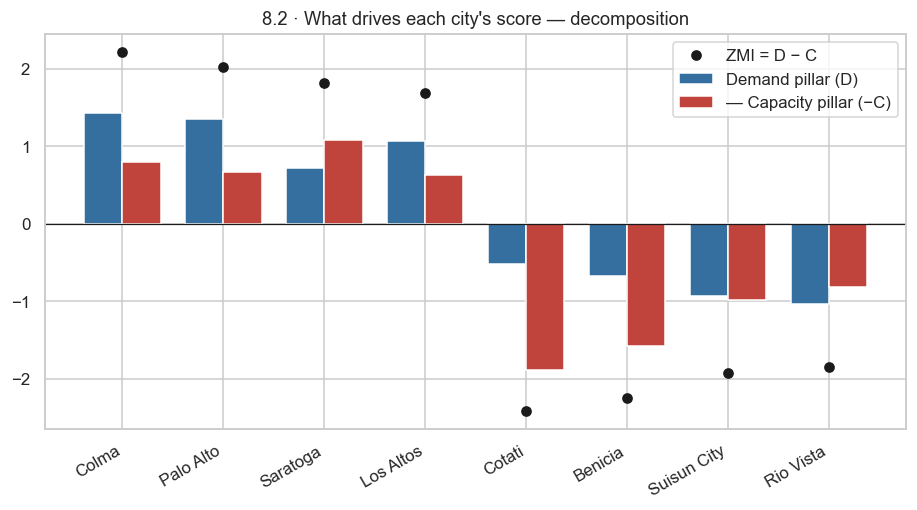

In [20]:
sel = pd.concat([df.nlargest(4, 'zmi_core'), df.nsmallest(4, 'zmi_core')])
fig, ax = plt.subplots(figsize=(8.5, 4.8))
x = np.arange(len(sel)); w = 0.38
ax.bar(x - w/2, sel['D_demand'], w, label='Demand pillar (D)', color='#356f9f')
ax.bar(x + w/2, -sel['C_capacity'], w, label='— Capacity pillar (−C)', color='#c1443c')
ax.plot(x, sel['zmi_core'], 'ko', label='ZMI = D − C')
ax.set_xticks(x, sel['jurisdiction'], rotation=30, ha='right')
ax.axhline(0, color='k', lw=0.8); ax.legend()
ax.set_title('8.2 · What drives each city\'s score — decomposition')
plt.tight_layout(); plt.show()

### 8.3 SB 79 exposure — where the state override will bite on July 1, 2026

MTC's draft SB 79 layers (April 2026) map the tiers where state law will override local zoning near
major transit. Crossing them with current zoning gives a forward-looking ranking: **high
`sb79_exposure` = much transit-adjacent land that is currently single-family-locked.**

In [21]:
cols = ['jurisdiction','county','sb79_share','sb79_tier1_share','sf_share',
        'sb79_exposure','zmi_core','rhna6_progress']
top_sb79 = df[df['sb79_share'] > 0].nlargest(15, 'sb79_exposure')[cols].round(3)
print(f"jurisdictions touched by draft SB 79 tiers: {(df['sb79_share'] > 0).sum()}/109")
top_sb79

jurisdictions touched by draft SB 79 tiers: 35/109


,jurisdiction,county,sb79_share,sb79_tier1_share,sf_share,sb79_exposure,zmi_core,rhna6_progress
77,San Francisco,San Francisco,0.690,0.152,0.514,0.355,0.694,0.074
13,Campbell,Santa Clara,0.285,0.000,0.675,0.192,-0.168,0.520
75,San Bruno,San Mateo,0.201,0.201,0.911,0.183,0.383,0.309
92,Sunnyvale,Santa Clara,0.226,0.066,0.718,0.162,-0.556,0.092
80,San Mateo,San Mateo,0.224,0.224,0.687,0.154,-1.033,0.094
90,South San Francisco,San Mateo,0.204,0.204,0.731,0.149,-0.291,0.215
8,Berkeley,Alameda,0.299,0.220,0.484,0.145,-0.459,0.182
21,Daly City,San Mateo,0.162,0.145,0.891,0.144,0.879,0.054
56,Oakland,Alameda,0.205,0.106,0.650,0.133,-0.613,0.103
48,Milpitas,Santa Clara,0.158,0.055,0.813,0.128,0.846,0.061


**Read:** the exposure ranking puts transit-served, single-family-locked, mid-to-high-ZMI
cities on top — the places where SB 79 changes what is legal the most. For ABAG/MTC this is a
prioritization list for technical assistance *before* the law's effective date (17 days after this
project's deadline). A scenario: if jurisdictions below the regional median of zoned capacity per
1k households were brought *to* that median, the region would add the following zoned headroom:

In [22]:
med = df['capacity6_per_1k'].median()
gap = (med - df['capacity6_per_1k']).clip(lower=0) * df['households_2020'] / 1000
print(f'regional median capacity: {med:.0f} units per 1k households')
print(f'zoned-capacity headroom if every below-median city reached the median: '
      f'{gap.sum():,.0f} units')
print('(a zoning scenario, NOT a production forecast — conversion rates in §7/H2 apply)')

regional median capacity: 94 units per 1k households
zoned-capacity headroom if every below-median city reached the median: 80,894 units
(a zoning scenario, NOT a production forecast — conversion rates in §7/H2 apply)


## 9. Discussion

**What the data shows.** (1) Residential land in the median Bay Area jurisdiction is ~85%
single-family-only, the highest-mismatch cities cluster in the job- and transit-rich Peninsula core
(P1, P4), and zoned capacity is *uncorrelated* with transit access — the region plans
transit-oriented growth that its zoning never made legal (H1). (2) Production
2018–2025 tracks *revealed* zoning room: pre-mandate capacity predicts permits; the new
state-mandated capacity does not yet (H2) — paper capacity converged before behavior did.
(3) The shortfall is concentrated by income band *and by structure*: above-moderate permits run
ahead of their need share while very-low-income units run far behind (C2); high-mismatch towns
permit ADUs and rebuilds, not apartments (median 1.4 multifamily units per 1k households over eight
years, 11× below the open group — C1); and low-income delivery is slowest in high-resource cities
(H3). (4) The forward-looking layers (SB 79 exposure, `permit_capture_2325`)
identify exactly which jurisdictions to watch as the 6th cycle unfolds (8.3).

**Limitations.** APR and sites-inventory data are *self-reported* (HCD audits but does not verify
parcel-level claims); APR unit counts include ADUs and single-family rebuilds, which flatters
low-density towns' progress (e.g., Atherton); 10 jurisdictions' 6th-cycle capacity is imputed
(`capacity_vintage` flags them); NZLUD friction covers 36/109 jurisdictions, so the friction pillar
is reported separately and never silently imputed; Zillow rents are missing for small cities;
vintages differ across sources (each documented in §2); and all conclusions are
jurisdiction-level — ecological inference to parcels or households is not claimed. We describe
results; causal claims are limited to what the cited literature establishes.

**What this adds.** A reproducible, validated, decomposable mismatch diagnostic at the jurisdiction
level, current through the April 2026 SB 79 draft maps — built only from verifiable public data.

## 10. Sources

**Government / regional:** [ABAG Final RHNA Plan 2023–31](https://abag.ca.gov/our-work/housing/rhna-regional-housing-needs-allocation) ·
[HCD APR data](https://data.ca.gov/dataset/housing-element-annual-progress-report-apr-data-by-jurisdiction-and-year) ·
[HCD sites inventory / open data tools](https://www.hcd.ca.gov/planning-and-community-development/housing-open-data-tools) ·
[MTC/ABAG Open Data](https://opendata.mtc.ca.gov/) (growth geographies, transit areas, EPCs, draft SB 79 layers) ·
[Plan Bay Area 2050+](https://abag.ca.gov/news/abag-mtc-adopt-final-plan-bay-area-2050-and-environmental-impact-report-0)

**Research:** Monkkonen, Lens & Manville, [*Built-out cities?*](https://pmc.ncbi.nlm.nih.gov/articles/PMC12308518/) ·
Mleczko & Desmond, [NZLUD](https://github.com/mtmleczko/nzlud) ·
Gyourko et al., [WRLURI](https://realestate.wharton.upenn.edu/working-papers/a-new-measure-of-the-local-regulatory-environment-for-housing-markets-the-wharton-residential-land-use-regulatory-index/) ·
Pennington, [*Does Building New Housing Cause Displacement?*](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=3867764) ·
Terner Center: [fees](https://ternercenter.berkeley.edu/research-and-policy/it-all-adds-up-development-fees/),
[SB 9](https://ternercenter.berkeley.edu/research-and-policy/sb-9-turns-one-applications/),
[2025 legislative round-up](https://ternercenter.berkeley.edu/research-and-policy/california-housing-supply-and-land-use-legislative-round-up-2025/) ·
[CA YIMBY ADU retrospective](https://cayimby.org/reports/california-adu-reform-a-retrospective/) ·
[OBI Bay Area zoning](https://belonging.berkeley.edu/single-family-zoning-san-francisco-bay-area)

**Market / census:** [Zillow Research](https://www.zillow.com/research/data/) · ACS via
[censusreporter](https://censusreporter.org) · [LEHD LODES](https://lehd.ces.census.gov/data/lodes/)

*Pipeline: `src/ingest_v3.py`, `src/ingest_sites6.py`, `src/assemble_v3.py` (+ `zmi_ingest.py`,
`ingest_obi.py`, `ingest_zillow.py`). Master table: `data/processed/bay_area_zmi_v3.csv`.*